In [ ]:
import torch
print(torch.cuda.is_available())

True


In [1]:
!pip install pandas scikit-learn matplotlib seaborn
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv("creditcard.csv")
df.head()
df["Class"].value_counts()

,count
Class,
0,284315
1,492


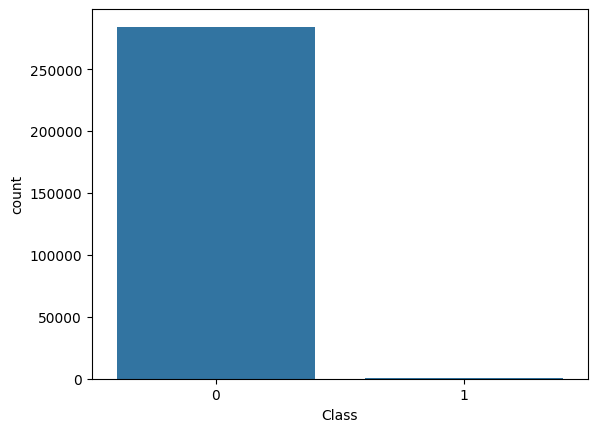

In [5]:
sns.countplot(x="Class", data=df)
plt.show()

In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

In [11]:
predictions = model.predict(X_test)

Accuracy: 0.9995786664794073


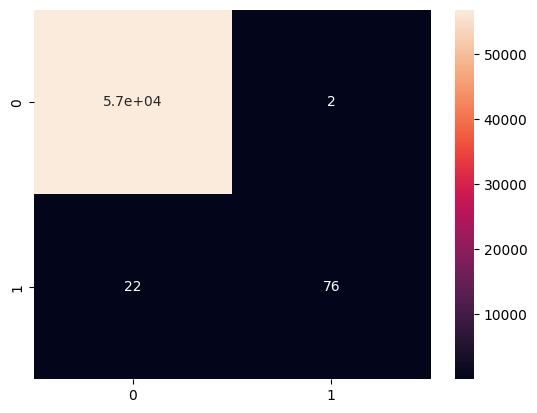

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [12]:
print("Accuracy:", accuracy_score(y_test, predictions))
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True)
plt.show()
print(classification_report(y_test, predictions))

In [13]:
import pickle

with open("fraud_detection_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [14]:
from google.colab import files

files.download("fraud_detection_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>